In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Google Drive location containing the processed BitBrains Parquet files
PROCESSED_DIR = Path(
    "/content/drive/MyDrive/bitbrains_processed"
)

print("Processed directory:", PROCESSED_DIR)
print("Exists:", PROCESSED_DIR.exists())

Processed directory: /content/drive/MyDrive/bitbrains_processed
Exists: True


In [ ]:
processed_files = sorted(
    PROCESSED_DIR.glob("vm_*.parquet")
)

print("Processed VM files:", len(processed_files))

Processed VM files: 1250


In [ ]:
vm_summary_path = PROCESSED_DIR / "bitbrains_vm_summary.csv"

print("Summary path:", vm_summary_path)
print("Exists:", vm_summary_path.exists())

vm_summary = pd.read_csv(vm_summary_path)

print("Shape:", vm_summary.shape)

display(vm_summary.head())

Summary path: /content/drive/MyDrive/bitbrains_processed/bitbrains_vm_summary.csv
Exists: True
Shape: (1250, 12)


,vm_id,rows,start_time,end_time,cpu_mean,cpu_max,memory_mean_kb,disk_read_mean_kbps,disk_write_mean_kbps,network_received_mean_kbps,network_transmitted_mean_kbps,memory_mean_gb
0,1,8634,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,4.022632,97.866667,396831.942014,9.068713,412.470582,12.548241,2.982650,0.378448
1,10,16140,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,0.237504,92.300000,11041.700677,0.614044,14.903408,0.957699,0.226334,0.010530
2,100,20255,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,0.288058,4.800000,152397.038741,0.000688,0.568226,0.014347,0.005816,0.145337
3,1000,8640,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,3.372504,24.966667,541334.976574,4.202037,160.068619,1.845062,4.281481,0.516257
4,1001,8640,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,0.260694,16.200000,117021.507037,1.078094,1.596767,0.423619,3.979221,0.111600


In [ ]:
feature_df = vm_summary.copy()

# Remove the duplicate memory representation
feature_df = feature_df.drop(columns=["memory_mean_kb"])

print("Feature table shape:", feature_df.shape)
print("\nColumns:")
for col in feature_df.columns:
    print("-", col)

display(feature_df.head())

Feature table shape: (1250, 11)

Columns:
- vm_id
- rows
- start_time
- end_time
- cpu_mean
- cpu_max
- disk_read_mean_kbps
- disk_write_mean_kbps
- network_received_mean_kbps
- network_transmitted_mean_kbps
- memory_mean_gb


,vm_id,rows,start_time,end_time,cpu_mean,cpu_max,disk_read_mean_kbps,disk_write_mean_kbps,network_received_mean_kbps,network_transmitted_mean_kbps,memory_mean_gb
0,1,8634,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,4.022632,97.866667,9.068713,412.470582,12.548241,2.982650,0.378448
1,10,16140,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,0.237504,92.300000,0.614044,14.903408,0.957699,0.226334,0.010530
2,100,20255,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,0.288058,4.800000,0.000688,0.568226,0.014347,0.005816,0.145337
3,1000,8640,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,3.372504,24.966667,4.202037,160.068619,1.845062,4.281481,0.516257
4,1001,8640,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,0.260694,16.200000,1.078094,1.596767,0.423619,3.979221,0.111600


In [ ]:
# Convert timestamps to datetime
feature_df["start_time"] = pd.to_datetime(
    feature_df["start_time"],
    utc=True
)

feature_df["end_time"] = pd.to_datetime(
    feature_df["end_time"],
    utc=True
)

# Observation coverage
feature_df["coverage_hours"] = (
    feature_df["end_time"] - feature_df["start_time"]
).dt.total_seconds() / 3600

# CPU burstiness: difference between peak and average utilization
feature_df["cpu_burst_gap"] = (
    feature_df["cpu_max"] - feature_df["cpu_mean"]
)

# Combined disk activity
feature_df["disk_activity_kbps"] = (
    feature_df["disk_read_mean_kbps"]
    + feature_df["disk_write_mean_kbps"]
)

# Combined network activity
feature_df["network_activity_kbps"] = (
    feature_df["network_received_mean_kbps"]
    + feature_df["network_transmitted_mean_kbps"]
)

# Overall I/O activity
feature_df["io_activity_kbps"] = (
    feature_df["disk_activity_kbps"]
    + feature_df["network_activity_kbps"]
)

display(
    feature_df[
        [
            "vm_id",
            "cpu_mean",
            "cpu_max",
            "cpu_burst_gap",
            "memory_mean_gb",
            "disk_activity_kbps",
            "network_activity_kbps",
            "io_activity_kbps",
            "coverage_hours"
        ]
    ].head()
)

,vm_id,cpu_mean,cpu_max,cpu_burst_gap,memory_mean_gb,disk_activity_kbps,network_activity_kbps,io_activity_kbps,coverage_hours
0,1,4.022632,97.866667,93.844034,0.378448,421.539294,15.530892,437.070186,719.986667
1,10,0.237504,92.300000,92.062496,0.010530,15.517451,1.184033,16.701485,719.986667
2,100,0.288058,4.800000,4.511942,0.145337,0.568914,0.020163,0.589077,719.986667
3,1000,3.372504,24.966667,21.594163,0.516257,164.270656,6.126543,170.397199,719.986667
4,1001,0.260694,16.200000,15.939306,0.111600,2.674861,4.402840,7.077701,719.986667


In [ ]:
feature_df = feature_df.rename(
    columns={
        "coverage_hours": "observation_span_hours"
    }
)

print(
    "Observation span (hours):",
    feature_df["observation_span_hours"].min(),
    "to",
    feature_df["observation_span_hours"].max()
)

Observation span (hours): 0.3333333333333333 to 719.9866666666667


In [ ]:
# CPU intensity relative to the 100% utilization scale
feature_df["cpu_intensity"] = (
    feature_df["cpu_mean"] / 100.0
)

# Peak CPU intensity
feature_df["cpu_peak_intensity"] = (
    feature_df["cpu_max"] / 100.0
)

# Memory relative to a 1 GB reference
feature_df["memory_intensity"] = (
    feature_df["memory_mean_gb"] / 1.0
)

# Relative contribution of disk read vs total disk activity
feature_df["disk_read_ratio"] = np.where(
    feature_df["disk_activity_kbps"] > 0,
    feature_df["disk_read_mean_kbps"]
    / feature_df["disk_activity_kbps"],
    0
)

# Relative contribution of network receive vs total network activity
feature_df["network_receive_ratio"] = np.where(
    feature_df["network_activity_kbps"] > 0,
    feature_df["network_received_mean_kbps"]
    / feature_df["network_activity_kbps"],
    0
)

display(
    feature_df[
        [
            "vm_id",
            "cpu_intensity",
            "cpu_peak_intensity",
            "memory_intensity",
            "disk_read_ratio",
            "network_receive_ratio"
        ]
    ].head()
)

,vm_id,cpu_intensity,cpu_peak_intensity,memory_intensity,disk_read_ratio,network_receive_ratio
0,1,0.040226,0.978667,0.378448,0.021513,0.807954
1,10,0.002375,0.923000,0.010530,0.039571,0.808845
2,100,0.002881,0.048000,0.145337,0.001209,0.711566
3,1000,0.033725,0.249667,0.516257,0.025580,0.301159
4,1001,0.002607,0.162000,0.111600,0.403047,0.096215


In [ ]:
# Resource-based cost index

import pandas as pd
import numpy as np

cost_features = feature_df.copy()

# Normalize resource intensity using min-max scaling
def min_max_scale(series):
    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series(0.0, index=series.index)

    return (series - min_val) / (max_val - min_val)


cost_features["cpu_score"] = min_max_scale(
    cost_features["cpu_intensity"]
)

cost_features["memory_score"] = min_max_scale(
    cost_features["memory_intensity"]
)

cost_features["disk_score"] = min_max_scale(
    cost_features["disk_read_ratio"]
)

cost_features["network_score"] = min_max_scale(
    cost_features["network_receive_ratio"]
)

# Weighted resource cost index
cost_features["resource_cost_index"] = (
    0.40 * cost_features["cpu_score"] +
    0.30 * cost_features["memory_score"] +
    0.15 * cost_features["disk_score"] +
    0.15 * cost_features["network_score"]
)

print("Cost feature table shape:", cost_features.shape)

cost_features[
    [
        "vm_id",
        "cpu_score",
        "memory_score",
        "disk_score",
        "network_score",
        "resource_cost_index"
    ]
].head()

Cost feature table shape: (1250, 26)


,vm_id,cpu_score,memory_score,disk_score,network_score,resource_cost_index
0,1,0.055696,0.028638,0.021526,0.807954,0.155292
1,10,0.003288,0.000797,0.039594,0.808845,0.128820
2,100,0.003988,0.010998,0.001210,0.711566,0.111811
3,1000,0.046695,0.039066,0.025594,0.301159,0.079411
4,1001,0.003609,0.008445,0.403275,0.096215,0.078901


In [ ]:
# Inspect resource cost index distribution

cost_index_summary = pd.DataFrame({
    "Metric": [
        "Minimum",
        "Mean",
        "Median",
        "Maximum",
        "Std Dev",
        "Near-zero VMs"
    ],
    "Value": [
        cost_features["resource_cost_index"].min(),
        cost_features["resource_cost_index"].mean(),
        cost_features["resource_cost_index"].median(),
        cost_features["resource_cost_index"].max(),
        cost_features["resource_cost_index"].std(),
        (cost_features["resource_cost_index"] < 0.001).sum()
    ]
})

display(cost_index_summary)

,Metric,Value
0,Minimum,1.424868e-07
1,Mean,1.691749e-01
2,Median,1.425367e-01
3,Maximum,7.730981e-01
4,Std Dev,1.333476e-01
5,Near-zero VMs,2.100000e+01


In [ ]:
#  Save final VM-level feature table

final_vm_features = cost_features[
    [
        "vm_id",
        "rows",
        "start_time",
        "end_time",
        "cpu_mean",
        "cpu_max",
        "cpu_burst_gap",
        "memory_mean_gb",
        "disk_activity_kbps",
        "network_activity_kbps",
        "io_activity_kbps",
        "observation_span_hours",
        "cpu_intensity",
        "cpu_peak_intensity",
        "memory_intensity",
        "disk_read_ratio",
        "network_receive_ratio",
        "cpu_score",
        "memory_score",
        "disk_score",
        "network_score",
        "resource_cost_index"
    ]
].copy()

FINAL_FEATURE_PATH = (
    "/content/drive/MyDrive/bitbrains_processed/"
    "bitbrains_vm_features.csv"
)

final_vm_features.to_csv(FINAL_FEATURE_PATH, index=False)

print("Final feature table saved.")
print("Path:", FINAL_FEATURE_PATH)
print("Shape:", final_vm_features.shape)

display(final_vm_features.head())

Final feature table saved.
Path: /content/drive/MyDrive/bitbrains_processed/bitbrains_vm_features.csv
Shape: (1250, 22)


,vm_id,rows,start_time,end_time,cpu_mean,cpu_max,cpu_burst_gap,memory_mean_gb,disk_activity_kbps,network_activity_kbps,...,cpu_intensity,cpu_peak_intensity,memory_intensity,disk_read_ratio,network_receive_ratio,cpu_score,memory_score,disk_score,network_score,resource_cost_index
0,1,8634,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,4.022632,97.866667,93.844034,0.378448,421.539294,15.530892,...,0.040226,0.978667,0.378448,0.021513,0.807954,0.055696,0.028638,0.021526,0.807954,0.155292
1,10,16140,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,0.237504,92.300000,92.062496,0.010530,15.517451,1.184033,...,0.002375,0.923000,0.010530,0.039571,0.808845,0.003288,0.000797,0.039594,0.808845,0.128820
2,100,20255,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,0.288058,4.800000,4.511942,0.145337,0.568914,0.020163,...,0.002881,0.048000,0.145337,0.001209,0.711566,0.003988,0.010998,0.001210,0.711566,0.111811
3,1000,8640,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,3.372504,24.966667,21.594163,0.516257,164.270656,6.126543,...,0.033725,0.249667,0.516257,0.025580,0.301159,0.046695,0.039066,0.025594,0.301159,0.079411
4,1001,8640,2013-08-12 13:40:46+00:00,2013-09-11 13:39:58+00:00,0.260694,16.200000,15.939306,0.111600,2.674861,4.402840,...,0.002607,0.162000,0.111600,0.403047,0.096215,0.003609,0.008445,0.403275,0.096215,0.078901


In [ ]:
#  Build 5-minute resource time series

from pathlib import Path
import pandas as pd
import numpy as np

RAW_DIR = Path("/content/drive/MyDrive/fastStorage/2013-8")
OUTPUT_DIR = Path("/content/drive/MyDrive/bitbrains_processed")

# Collect all VM files
csv_files = list(RAW_DIR.glob("*.csv"))

print("CSV files found:", len(csv_files))

# Store aggregated chunks here
time_chunks = []

for i, file_path in enumerate(csv_files, start=1):

    try:
        df = pd.read_csv(
            file_path,
            sep=r";\t",
            engine="python"
        )

        # Clean column names
        df.columns = df.columns.str.strip()

        # Convert numeric columns
        numeric_cols = [
            "CPU cores",
            "CPU capacity provisioned [MHZ]",
            "CPU usage [MHZ]",
            "CPU usage [%]",
            "Memory capacity provisioned [KB]",
            "Memory usage [KB]",
            "Disk read throughput [KB/s]",
            "Disk write throughput [KB/s]",
            "Network received throughput [KB/s]",
            "Network transmitted throughput [KB/s]"
        ]

        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # Timestamp
        df["timestamp"] = pd.to_datetime(
            pd.to_numeric(df["Timestamp [ms]"], errors="coerce"),
            unit="s",
            utc=True
        )

        # Remove invalid timestamps
        df = df.dropna(subset=["timestamp"])

        # VM identifier from filename
        vm_id = int(file_path.stem)
        df["vm_id"] = vm_id

        # 5-minute bucket
        df["time_bucket"] = df["timestamp"].dt.floor("5min")

        # Resource activity
        df["disk_activity_kbps"] = (
            df["Disk read throughput [KB/s]"].fillna(0)
            + df["Disk write throughput [KB/s]"].fillna(0)
        )

        df["network_activity_kbps"] = (
            df["Network received throughput [KB/s]"].fillna(0)
            + df["Network transmitted throughput [KB/s]"].fillna(0)
        )

        # Active VM definition
        df["active_vm"] = (
            df["CPU usage [%]"].fillna(0) > 0
        ).astype(int)

        # Aggregate this VM
        grouped = (
            df.groupby("time_bucket")
            .agg(
                cpu_mean=("CPU usage [%]", "mean"),
                memory_mean_kb=("Memory usage [KB]", "mean"),
                disk_activity_kbps=("disk_activity_kbps", "mean"),
                network_activity_kbps=("network_activity_kbps", "mean"),
                active_vm=("active_vm", "max")
            )
            .reset_index()
        )

        time_chunks.append(grouped)

        # Progress
        if i % 100 == 0 or i == len(csv_files):
            print(f"Processed {i}/{len(csv_files)} files")

    except Exception as e:
        print(f"Skipped {file_path.name}: {e}")


# Combine VM-level time buckets
time_df = pd.concat(time_chunks, ignore_index=True)

# Aggregate across VMs
resource_ts = (
    time_df.groupby("time_bucket")
    .agg(
        cpu_mean=("cpu_mean", "mean"),
        memory_mean_kb=("memory_mean_kb", "mean"),
        disk_activity_kbps=("disk_activity_kbps", "mean"),
        network_activity_kbps=("network_activity_kbps", "mean"),
        active_vms=("active_vm", "sum")
    )
    .reset_index()
)

# Convert memory KB → GB
resource_ts["memory_mean_gb"] = (
    resource_ts["memory_mean_kb"] / (1024 ** 2)
)

# Normalize each resource dimension
def min_max_scale(series):
    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series(0.0, index=series.index)

    return (series - min_val) / (max_val - min_val)


resource_ts["cpu_score"] = min_max_scale(
    resource_ts["cpu_mean"]
)

resource_ts["memory_score"] = min_max_scale(
    resource_ts["memory_mean_gb"]
)

resource_ts["disk_score"] = min_max_scale(
    resource_ts["disk_activity_kbps"]
)

resource_ts["network_score"] = min_max_scale(
    resource_ts["network_activity_kbps"]
)

# Combined resource cost signal
resource_ts["resource_cost_index"] = (
    0.40 * resource_ts["cpu_score"]
    + 0.30 * resource_ts["memory_score"]
    + 0.15 * resource_ts["disk_score"]
    + 0.15 * resource_ts["network_score"]
)

# Sort chronologically
resource_ts = resource_ts.sort_values("time_bucket").reset_index(drop=True)

# Save
TIME_SERIES_PATH = (
    OUTPUT_DIR / "bitbrains_5min_resource_timeseries.csv"
)

resource_ts.to_csv(TIME_SERIES_PATH, index=False)

print("\nTime series created successfully.")
print("Shape:", resource_ts.shape)
print("Path:", TIME_SERIES_PATH)

display(resource_ts.head())

CSV files found: 1250
Processed 100/1250 files
Processed 200/1250 files
Processed 300/1250 files
Processed 400/1250 files
Processed 500/1250 files
Processed 600/1250 files
Processed 700/1250 files
Processed 800/1250 files
Processed 900/1250 files
Processed 1000/1250 files
Processed 1100/1250 files
Processed 1200/1250 files
Processed 1250/1250 files

Time series created successfully.
Shape: (8640, 12)
Path: /content/drive/MyDrive/bitbrains_processed/bitbrains_5min_resource_timeseries.csv


,time_bucket,cpu_mean,memory_mean_kb,disk_activity_kbps,network_activity_kbps,active_vms,memory_mean_gb,cpu_score,memory_score,disk_score,network_score,resource_cost_index
0,2013-08-12 13:40:00+00:00,9.683054,773476.700834,268.118090,237.625252,924,0.737645,0.537442,0.253019,0.069119,0.057561,0.309884
1,2013-08-12 13:45:00+00:00,9.811374,713465.677165,262.730797,250.486704,969,0.680414,0.546432,0.226304,0.065656,0.061059,0.305471
2,2013-08-12 13:50:00+00:00,9.095303,706308.206336,293.765438,254.551917,906,0.673588,0.496263,0.223118,0.085604,0.062165,0.287606
3,2013-08-12 13:55:00+00:00,7.343816,711822.267357,261.489772,135.761297,926,0.678847,0.373550,0.225572,0.064858,0.029850,0.231298
4,2013-08-12 14:00:00+00:00,7.133512,732891.662698,265.543630,218.948691,960,0.698940,0.358816,0.234952,0.067464,0.052480,0.232003


In [ ]:
# Validate the 5-minute resource time series

ts = pd.read_csv(
    "/content/drive/MyDrive/bitbrains_processed/bitbrains_5min_resource_timeseries.csv",
    parse_dates=["time_bucket"]
)

print("Shape:", ts.shape)
print("Start:", ts["time_bucket"].min())
print("End:", ts["time_bucket"].max())

# Check duplicate timestamps
print("\nDuplicate timestamps:", ts["time_bucket"].duplicated().sum())

# Check missing values
print("\nMissing values:")
print(ts.isna().sum())

# Check 5-minute continuity
time_diff = ts["time_bucket"].sort_values().diff().dropna()

print("\nTime interval distribution:")
print(time_diff.value_counts().head())

# Basic range checks
print("\nMinimum values:")
print(ts.select_dtypes(include="number").min())

print("\nMaximum values:")
print(ts.select_dtypes(include="number").max())

Shape: (8640, 12)
Start: 2013-08-12 13:40:00+00:00
End: 2013-09-11 13:35:00+00:00

Duplicate timestamps: 0

Missing values:
time_bucket              0
cpu_mean                 0
memory_mean_kb           0
disk_activity_kbps       0
network_activity_kbps    0
active_vms               0
memory_mean_gb           0
cpu_score                0
memory_score             0
disk_score               0
network_score            0
resource_cost_index      0
dtype: int64

Time interval distribution:
time_bucket
0 days 00:05:00    8639
Name: count, dtype: int64

Minimum values:
cpu_mean                      2.012112
memory_mean_kb           205105.827202
disk_activity_kbps          160.584799
network_activity_kbps        26.030641
active_vms                  226.000000
memory_mean_gb                0.195604
cpu_score                     0.000000
memory_score                  0.000000
disk_score                    0.000000
network_score                 0.000000
resource_cost_index           0.011826
dt

In [ ]:
# Create normalized estimated cost signal from Bitbrains resource usage

ts = pd.read_csv(
    "/content/drive/MyDrive/bitbrains_processed/bitbrains_5min_resource_timeseries.csv",
    parse_dates=["time_bucket"]
)

# Normalize resource cost index to a 0-100 scale
min_cost = ts["resource_cost_index"].min()
max_cost = ts["resource_cost_index"].max()

ts["estimated_cost_index"] = (
    (ts["resource_cost_index"] - min_cost)
    / (max_cost - min_cost)
) * 100

# Convert 5-minute data into hourly aggregates
hourly = (
    ts.set_index("time_bucket")
      .resample("1h")
      .agg({
          "cpu_mean": "mean",
          "memory_mean_gb": "mean",
          "disk_activity_kbps": "mean",
          "network_activity_kbps": "mean",
          "active_vms": "mean",
          "resource_cost_index": "mean",
          "estimated_cost_index": "mean"
      })
      .reset_index()
)

print("Hourly time series shape:", hourly.shape)
print("\nColumns:")
print(hourly.columns.tolist())

print("\nFirst 5 rows:")
display(hourly.head())

print("\nEstimated cost index statistics:")
display(
    hourly["estimated_cost_index"].describe()
)

# Save
hourly_path = (
    "/content/drive/MyDrive/bitbrains_processed/"
    "bitbrains_hourly_cost_timeseries.csv"
)

hourly.to_csv(hourly_path, index=False)

print("\nSaved:")
print(hourly_path)

Hourly time series shape: (721, 8)

Columns:
['time_bucket', 'cpu_mean', 'memory_mean_gb', 'disk_activity_kbps', 'network_activity_kbps', 'active_vms', 'resource_cost_index', 'estimated_cost_index']

First 5 rows:


,time_bucket,cpu_mean,memory_mean_gb,disk_activity_kbps,network_activity_kbps,active_vms,resource_cost_index,estimated_cost_index
0,2013-08-12 13:00:00+00:00,8.983387,0.692623,271.526024,219.606292,931.250000,0.283565,44.682019
1,2013-08-12 14:00:00+00:00,5.424531,0.571483,257.485959,89.581368,920.583333,0.160205,24.397998
2,2013-08-12 15:00:00+00:00,8.042373,0.682148,251.989447,100.663045,927.416667,0.248989,38.996738
3,2013-08-12 16:00:00+00:00,11.640584,0.710577,224.932377,55.266386,925.166667,0.349348,55.498785
4,2013-08-12 17:00:00+00:00,11.639388,0.702552,289.969175,68.445456,926.500000,0.354999,56.427959



Estimated cost index statistics:


,estimated_cost_index
count,721.000000
mean,38.231057
std,19.702646
min,1.335226
25%,21.801259
50%,36.331235
75%,55.951294
max,86.277015



Saved:
/content/drive/MyDrive/bitbrains_processed/bitbrains_hourly_cost_timeseries.csv


In [ ]:
# Validate hourly cost signal

hourly = pd.read_csv(
    "/content/drive/MyDrive/bitbrains_processed/bitbrains_hourly_cost_timeseries.csv",
    parse_dates=["time_bucket"]
)

# Check hourly continuity
hourly_diff = hourly["time_bucket"].sort_values().diff().dropna()

print("Rows:", len(hourly))
print("Start:", hourly["time_bucket"].min())
print("End:", hourly["time_bucket"].max())

print("\nDuplicate timestamps:",
      hourly["time_bucket"].duplicated().sum())

print("\nHourly interval distribution:")
print(hourly_diff.value_counts().head())

print("\nMissing values:")
print(hourly.isna().sum())

print("\nCost signal statistics:")
print(hourly["estimated_cost_index"].describe())

print("\nLowest-cost hours:")
display(
    hourly.nsmallest(5, "estimated_cost_index")[
        ["time_bucket", "active_vms", "resource_cost_index", "estimated_cost_index"]
    ]
)

print("\nHighest-cost hours:")
display(
    hourly.nlargest(5, "estimated_cost_index")[
        ["time_bucket", "active_vms", "resource_cost_index", "estimated_cost_index"]
    ]
)

Rows: 721
Start: 2013-08-12 13:00:00+00:00
End: 2013-09-11 13:00:00+00:00

Duplicate timestamps: 0

Hourly interval distribution:
time_bucket
0 days 01:00:00    720
Name: count, dtype: int64

Missing values:
time_bucket              0
cpu_mean                 0
memory_mean_gb           0
disk_activity_kbps       0
network_activity_kbps    0
active_vms               0
resource_cost_index      0
estimated_cost_index     0
dtype: int64

Cost signal statistics:
count    721.000000
mean      38.231057
std       19.702646
min        1.335226
25%       21.801259
50%       36.331235
75%       55.951294
max       86.277015
Name: estimated_cost_index, dtype: float64

Lowest-cost hours:


,time_bucket,active_vms,resource_cost_index,estimated_cost_index
329,2013-08-26 06:00:00+00:00,945.250000,0.019946,1.335226
321,2013-08-25 22:00:00+00:00,942.083333,0.026785,2.459714
328,2013-08-26 05:00:00+00:00,943.166667,0.027107,2.512665
327,2013-08-26 04:00:00+00:00,935.416667,0.028436,2.731152
326,2013-08-26 03:00:00+00:00,939.666667,0.036818,4.109438



Highest-cost hours:


,time_bucket,active_vms,resource_cost_index,estimated_cost_index
107,2013-08-17 00:00:00+00:00,949.916667,0.536530,86.277015
108,2013-08-17 01:00:00+00:00,951.250000,0.516946,83.056890
242,2013-08-22 15:00:00+00:00,963.166667,0.514040,82.578969
109,2013-08-17 02:00:00+00:00,950.916667,0.512356,82.302040
239,2013-08-22 12:00:00+00:00,957.333333,0.502095,80.614856


In [ ]:
# Remove partial first and last hours

hourly = pd.read_csv(
    "/content/drive/MyDrive/bitbrains_processed/bitbrains_hourly_cost_timeseries.csv",
    parse_dates=["time_bucket"]
)

# Remove the first and last hourly buckets
hourly_clean = hourly.iloc[1:-1].copy()

print("Original rows:", len(hourly))
print("Clean rows:", len(hourly_clean))

print("\nNew start:", hourly_clean["time_bucket"].min())
print("New end:", hourly_clean["time_bucket"].max())

print("\nTime interval check:")
print(
    hourly_clean["time_bucket"]
    .sort_values()
    .diff()
    .dropna()
    .value_counts()
)

# Save cleaned hourly dataset
clean_path = (
    "/content/drive/MyDrive/bitbrains_processed/"
    "bitbrains_hourly_cost_timeseries_clean.csv"
)

hourly_clean.to_csv(clean_path, index=False)

print("\nSaved:")
print(clean_path)

Original rows: 721
Clean rows: 719

New start: 2013-08-12 14:00:00+00:00
New end: 2013-09-11 12:00:00+00:00

Time interval check:
time_bucket
0 days 01:00:00    718
Name: count, dtype: int64

Saved:
/content/drive/MyDrive/bitbrains_processed/bitbrains_hourly_cost_timeseries_clean.csv


In [ ]:
# Create the forecasting target

hourly = pd.read_csv(
    "/content/drive/MyDrive/bitbrains_processed/"
    "bitbrains_hourly_cost_timeseries_clean.csv",
    parse_dates=["time_bucket"]
)

hourly = hourly.sort_values("time_bucket").reset_index(drop=True)

# Next-hour target
hourly["target_next_hour_cost"] = (
    hourly["estimated_cost_index"].shift(-1)
)

# The final row has no future target, so remove it
forecast_df = hourly.dropna(
    subset=["target_next_hour_cost"]
).copy()

print("Original rows:", len(hourly))
print("Forecasting rows:", len(forecast_df))

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nTarget statistics:")
print(forecast_df["target_next_hour_cost"].describe())

print("\nFirst 5 forecasting records:")
display(
    forecast_df[
        [
            "time_bucket",
            "estimated_cost_index",
            "target_next_hour_cost"
        ]
    ].head()
)

print("\nLast 5 forecasting records:")
display(
    forecast_df[
        [
            "time_bucket",
            "estimated_cost_index",
            "target_next_hour_cost"
        ]
    ].tail()
)

Original rows: 719
Forecasting rows: 718

Columns:
['time_bucket', 'cpu_mean', 'memory_mean_gb', 'disk_activity_kbps', 'network_activity_kbps', 'active_vms', 'resource_cost_index', 'estimated_cost_index', 'target_next_hour_cost']

Target statistics:
count    718.000000
mean      38.236066
std       19.735084
min        1.335226
25%       21.781055
50%       36.302878
75%       55.972937
max       86.277015
Name: target_next_hour_cost, dtype: float64

First 5 forecasting records:


,time_bucket,estimated_cost_index,target_next_hour_cost
0,2013-08-12 14:00:00+00:00,24.397998,38.996738
1,2013-08-12 15:00:00+00:00,38.996738,55.498785
2,2013-08-12 16:00:00+00:00,55.498785,56.427959
3,2013-08-12 17:00:00+00:00,56.427959,54.375590
4,2013-08-12 18:00:00+00:00,54.375590,54.391908



Last 5 forecasting records:


,time_bucket,estimated_cost_index,target_next_hour_cost
713,2013-09-11 07:00:00+00:00,10.253815,14.681374
714,2013-09-11 08:00:00+00:00,14.681374,41.699293
715,2013-09-11 09:00:00+00:00,41.699293,32.758115
716,2013-09-11 10:00:00+00:00,32.758115,33.046694
717,2013-09-11 11:00:00+00:00,33.046694,46.714217


In [ ]:
# Create the forecasting target

hourly = pd.read_csv(
    "/content/drive/MyDrive/bitbrains_processed/"
    "bitbrains_hourly_cost_timeseries_clean.csv",
    parse_dates=["time_bucket"]
)

hourly = hourly.sort_values("time_bucket").reset_index(drop=True)

# Next-hour target
hourly["target_next_hour_cost"] = (
    hourly["estimated_cost_index"].shift(-1)
)

# The final row has no future target, so remove it
forecast_df = hourly.dropna(
    subset=["target_next_hour_cost"]
).copy()

print("Original rows:", len(hourly))
print("Forecasting rows:", len(forecast_df))

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nTarget statistics:")
print(forecast_df["target_next_hour_cost"].describe())

print("\nFirst 5 forecasting records:")
display(
    forecast_df[
        [
            "time_bucket",
            "estimated_cost_index",
            "target_next_hour_cost"
        ]
    ].head()
)

print("\nLast 5 forecasting records:")
display(
    forecast_df[
        [
            "time_bucket",
            "estimated_cost_index",
            "target_next_hour_cost"
        ]
    ].tail()
)

Original rows: 719
Forecasting rows: 718

Columns:
['time_bucket', 'cpu_mean', 'memory_mean_gb', 'disk_activity_kbps', 'network_activity_kbps', 'active_vms', 'resource_cost_index', 'estimated_cost_index', 'target_next_hour_cost']

Target statistics:
count    718.000000
mean      38.236066
std       19.735084
min        1.335226
25%       21.781055
50%       36.302878
75%       55.972937
max       86.277015
Name: target_next_hour_cost, dtype: float64

First 5 forecasting records:


,time_bucket,estimated_cost_index,target_next_hour_cost
0,2013-08-12 14:00:00+00:00,24.397998,38.996738
1,2013-08-12 15:00:00+00:00,38.996738,55.498785
2,2013-08-12 16:00:00+00:00,55.498785,56.427959
3,2013-08-12 17:00:00+00:00,56.427959,54.375590
4,2013-08-12 18:00:00+00:00,54.375590,54.391908



Last 5 forecasting records:


,time_bucket,estimated_cost_index,target_next_hour_cost
713,2013-09-11 07:00:00+00:00,10.253815,14.681374
714,2013-09-11 08:00:00+00:00,14.681374,41.699293
715,2013-09-11 09:00:00+00:00,41.699293,32.758115
716,2013-09-11 10:00:00+00:00,32.758115,33.046694
717,2013-09-11 11:00:00+00:00,33.046694,46.714217


In [ ]:
# Load the forecasting dataset
import pandas as pd

FORECAST_PATH = "/content/drive/MyDrive/bitbrains_processed/bitbrains_hourly_cost_timeseries.csv"

df = pd.read_csv(FORECAST_PATH, parse_dates=["time_bucket"])

# Create next-hour target
df = df.sort_values("time_bucket").reset_index(drop=True)
df["target_next_hour_cost"] = df["estimated_cost_index"].shift(-1)

# Remove final row because it has no next-hour target
df = df.dropna(subset=["target_next_hour_cost"]).reset_index(drop=True)

# Chronological split
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Total:", len(df))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain period:")
print(train_df["time_bucket"].min(), "→", train_df["time_bucket"].max())

print("\nValidation period:")
print(val_df["time_bucket"].min(), "→", val_df["time_bucket"].max())

print("\nTest period:")
print(test_df["time_bucket"].min(), "→", test_df["time_bucket"].max())

Total: 720
Train: 503
Validation: 109
Test: 108

Train period:
2013-08-12 13:00:00+00:00 → 2013-09-02 11:00:00+00:00

Validation period:
2013-09-02 12:00:00+00:00 → 2013-09-07 00:00:00+00:00

Test period:
2013-09-07 01:00:00+00:00 → 2013-09-11 12:00:00+00:00


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Naive forecast:
# Predict the next-hour cost as the current-hour cost
y_val = val_df["target_next_hour_cost"]
val_pred_naive = val_df["estimated_cost_index"]

mae = mean_absolute_error(y_val, val_pred_naive)
rmse = np.sqrt(mean_squared_error(y_val, val_pred_naive))

print("Naive Baseline — Validation")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

Naive Baseline — Validation
MAE : 5.9103
RMSE: 8.9271


In [ ]:
# 6-hour rolling mean baseline

history = train_df["estimated_cost_index"].tolist()

rolling_predictions = []

for value in val_df["estimated_cost_index"]:
    # Use the most recent 6 observed values
    recent_values = history[-6:]
    prediction = np.mean(recent_values)

    rolling_predictions.append(prediction)

    # After making the prediction, the current observation becomes available
    history.append(value)

val_pred_rolling = np.array(rolling_predictions)

mae_rolling = mean_absolute_error(
    val_df["target_next_hour_cost"],
    val_pred_rolling
)

rmse_rolling = np.sqrt(
    mean_squared_error(
        val_df["target_next_hour_cost"],
        val_pred_rolling
    )
)

print("6-Hour Rolling Mean Baseline — Validation")
print(f"MAE : {mae_rolling:.4f}")
print(f"RMSE: {rmse_rolling:.4f}")

6-Hour Rolling Mean Baseline — Validation
MAE : 12.3060
RMSE: 16.8972


In [ ]:
# Prepare ML features and target

feature_cols = [
    "cpu_mean",
    "memory_mean_gb",
    "disk_activity_kbps",
    "network_activity_kbps",
    "active_vms",
    "resource_cost_index",
    "estimated_cost_index"
]

target_col = "target_next_hour_cost"

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFeatures:")
print(feature_cols)

print("\nMissing values in training features:")
print(X_train.isna().sum())

X_train: (503, 7)
y_train: (503,)
X_val: (109, 7)
y_val: (109,)
X_test: (108, 7)
y_test: (108,)

Features:
['cpu_mean', 'memory_mean_gb', 'disk_activity_kbps', 'network_activity_kbps', 'active_vms', 'resource_cost_index', 'estimated_cost_index']

Missing values in training features:
cpu_mean                 0
memory_mean_gb           0
disk_activity_kbps       0
network_activity_kbps    0
active_vms               0
resource_cost_index      0
estimated_cost_index     0
dtype: int64


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

# Validation prediction
y_val_pred = xgb_model.predict(X_val)

# Metrics
xgb_mae = mean_absolute_error(y_val, y_val_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print("XGBoost — Validation")
print(f"MAE : {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")

print("\nComparison with Naive Baseline")
print(f"Naive MAE : 5.9103")
print(f"XGB MAE   : {xgb_mae:.4f}")

XGBoost — Validation
MAE : 6.9137
RMSE: 9.2417

Comparison with Naive Baseline
Naive MAE : 5.9103
XGB MAE   : 6.9137


In [ ]:
# Create time-series lag and rolling features

model_df = df.copy()

# Historical cost lags
for lag in [1, 2, 3, 6, 12, 24]:
    model_df[f"cost_lag_{lag}"] = (
        model_df["estimated_cost_index"].shift(lag)
    )

# Historical rolling statistics
model_df["cost_roll_mean_3"] = (
    model_df["estimated_cost_index"]
    .shift(1)
    .rolling(3)
    .mean()
)

model_df["cost_roll_mean_6"] = (
    model_df["estimated_cost_index"]
    .shift(1)
    .rolling(6)
    .mean()
)

model_df["cost_roll_std_6"] = (
    model_df["estimated_cost_index"]
    .shift(1)
    .rolling(6)
    .std()
)

# Remove rows where lag/rolling features are unavailable
model_df = model_df.dropna().reset_index(drop=True)

print("Time-series ML dataset shape:", model_df.shape)

print("\nNew features:")
print([
    "cost_lag_1",
    "cost_lag_2",
    "cost_lag_3",
    "cost_lag_6",
    "cost_lag_12",
    "cost_lag_24",
    "cost_roll_mean_3",
    "cost_roll_mean_6",
    "cost_roll_std_6"
])

print("\nMissing values:")
print(model_df.isna().sum().sum())

print("\nFirst 3 rows:")
display(
    model_df[
        [
            "time_bucket",
            "estimated_cost_index",
            "target_next_hour_cost",
            "cost_lag_1",
            "cost_lag_6",
            "cost_lag_24",
            "cost_roll_mean_6"
        ]
    ].head(3)
)

Time-series ML dataset shape: (696, 18)

New features:
['cost_lag_1', 'cost_lag_2', 'cost_lag_3', 'cost_lag_6', 'cost_lag_12', 'cost_lag_24', 'cost_roll_mean_3', 'cost_roll_mean_6', 'cost_roll_std_6']

Missing values:
0

First 3 rows:


,time_bucket,estimated_cost_index,target_next_hour_cost,cost_lag_1,cost_lag_6,cost_lag_24,cost_roll_mean_6
0,2013-08-13 13:00:00+00:00,61.739955,61.438024,50.926716,56.724028,44.682019,57.892917
1,2013-08-13 14:00:00+00:00,61.438024,58.165152,61.739955,63.066703,24.397998,58.728905
2,2013-08-13 15:00:00+00:00,58.165152,48.619260,61.438024,58.939051,38.996738,58.457458


In [ ]:
# Chronological split for the time-series ML dataset

n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

ts_train = model_df.iloc[:train_end].copy()
ts_val = model_df.iloc[train_end:val_end].copy()
ts_test = model_df.iloc[val_end:].copy()

print("Total:", len(model_df))
print("Train:", len(ts_train))
print("Validation:", len(ts_val))
print("Test:", len(ts_test))

print("\nTrain period:")
print(ts_train["time_bucket"].min(), "→", ts_train["time_bucket"].max())

print("\nValidation period:")
print(ts_val["time_bucket"].min(), "→", ts_val["time_bucket"].max())

print("\nTest period:")
print(ts_test["time_bucket"].min(), "→", ts_test["time_bucket"].max())

Total: 696
Train: 487
Validation: 104
Test: 105

Train period:
2013-08-13 13:00:00+00:00 → 2013-09-02 19:00:00+00:00

Validation period:
2013-09-02 20:00:00+00:00 → 2013-09-07 03:00:00+00:00

Test period:
2013-09-07 04:00:00+00:00 → 2013-09-11 12:00:00+00:00


In [ ]:
# Features for the time-series XGBoost model

ts_feature_cols = [
    "cpu_mean",
    "memory_mean_gb",
    "disk_activity_kbps",
    "network_activity_kbps",
    "active_vms",
    "resource_cost_index",
    "estimated_cost_index",
    "cost_lag_1",
    "cost_lag_2",
    "cost_lag_3",
    "cost_lag_6",
    "cost_lag_12",
    "cost_lag_24",
    "cost_roll_mean_3",
    "cost_roll_mean_6",
    "cost_roll_std_6"
]

target_col = "target_next_hour_cost"

X_ts_train = ts_train[ts_feature_cols]
y_ts_train = ts_train[target_col]

X_ts_val = ts_val[ts_feature_cols]
y_ts_val = ts_val[target_col]

X_ts_test = ts_test[ts_feature_cols]
y_ts_test = ts_test[target_col]

print("X_train:", X_ts_train.shape)
print("y_train:", y_ts_train.shape)

print("X_validation:", X_ts_val.shape)
print("y_validation:", y_ts_val.shape)

print("X_test:", X_ts_test.shape)
print("y_test:", y_ts_test.shape)

print("\nTotal features:", len(ts_feature_cols))

print("\nMissing values:")
print(X_ts_train.isna().sum().sum())

X_train: (487, 16)
y_train: (487,)
X_validation: (104, 16)
y_validation: (104,)
X_test: (105, 16)
y_test: (105,)

Total features: 16

Missing values:
0


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_ts_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_ts_model.fit(
    X_ts_train,
    y_ts_train
)

# Validation prediction
y_ts_val_pred = xgb_ts_model.predict(X_ts_val)

# Metrics
ts_xgb_mae = mean_absolute_error(
    y_ts_val,
    y_ts_val_pred
)

ts_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_ts_val,
        y_ts_val_pred
    )
)

print("Lag-Enhanced XGBoost — Validation")
print(f"MAE : {ts_xgb_mae:.4f}")
print(f"RMSE: {ts_xgb_rmse:.4f}")

print("\nBenchmark")
print(f"Naive MAE : 5.9103")
print(f"XGB MAE   : {ts_xgb_mae:.4f}")

Lag-Enhanced XGBoost — Validation
MAE : 7.1204
RMSE: 9.3867

Benchmark
Naive MAE : 5.9103
XGB MAE   : 7.1204


In [ ]:
# Resource-only feature set

resource_features = [
    "cpu_mean",
    "memory_mean_gb",
    "disk_activity_kbps",
    "network_activity_kbps",
    "active_vms",
    "resource_cost_index"
]

X_res_train = ts_train[resource_features]
y_res_train = ts_train["target_next_hour_cost"]

X_res_val = ts_val[resource_features]
y_res_val = ts_val["target_next_hour_cost"]

X_res_test = ts_test[resource_features]
y_res_test = ts_test["target_next_hour_cost"]

print("Resource-only features:")
print(resource_features)

print("\nShapes:")
print("Train:", X_res_train.shape)
print("Validation:", X_res_val.shape)
print("Test:", X_res_test.shape)

print("\nMissing values:")
print(X_res_train.isna().sum().sum())

Resource-only features:
['cpu_mean', 'memory_mean_gb', 'disk_activity_kbps', 'network_activity_kbps', 'active_vms', 'resource_cost_index']

Shapes:
Train: (487, 6)
Validation: (104, 6)
Test: (105, 6)

Missing values:
0


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

resource_xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

resource_xgb_model.fit(
    X_res_train,
    y_res_train
)

# Validation prediction
y_val_pred_resource = resource_xgb_model.predict(
    X_res_val
)

# Metrics
resource_xgb_mae = mean_absolute_error(
    y_res_val,
    y_val_pred_resource
)

resource_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_res_val,
        y_val_pred_resource
    )
)

print("Resource-only XGBoost — Validation")
print(f"MAE : {resource_xgb_mae:.4f}")
print(f"RMSE: {resource_xgb_rmse:.4f}")

print("\nComparison with Naive Baseline")
print(f"Naive MAE          : 5.9103")
print(f"Resource-only XGB  : {resource_xgb_mae:.4f}")

if resource_xgb_mae < 5.9103:
    print("\nResult: Resource-only XGBoost BEATS the Naive baseline.")
else:
    print("\nResult: Resource-only XGBoost does NOT beat the Naive baseline.")

Resource-only XGBoost — Validation
MAE : 7.0574
RMSE: 9.8274

Comparison with Naive Baseline
Naive MAE          : 5.9103
Resource-only XGB  : 7.0574

Result: Resource-only XGBoost does NOT beat the Naive baseline.


In [ ]:
import pandas as pd
import numpy as np

# Load hourly dataset
hourly_df = pd.read_csv(
    "/content/drive/MyDrive/bitbrains_processed/bitbrains_hourly_cost_timeseries.csv",
    parse_dates=["time_bucket"]
)

hourly_df = hourly_df.sort_values("time_bucket").reset_index(drop=True)

# --------------------------------------------------
# 1. Time-based features
# --------------------------------------------------

hourly_df["hour"] = hourly_df["time_bucket"].dt.hour
hourly_df["day_of_week"] = hourly_df["time_bucket"].dt.dayofweek
hourly_df["day_of_month"] = hourly_df["time_bucket"].dt.day

hourly_df["is_weekend"] = (
    hourly_df["day_of_week"] >= 5
).astype(int)

# Cyclic encoding
hourly_df["hour_sin"] = np.sin(
    2 * np.pi * hourly_df["hour"] / 24
)

hourly_df["hour_cos"] = np.cos(
    2 * np.pi * hourly_df["hour"] / 24
)

hourly_df["dow_sin"] = np.sin(
    2 * np.pi * hourly_df["day_of_week"] / 7
)

hourly_df["dow_cos"] = np.cos(
    2 * np.pi * hourly_df["day_of_week"] / 7
)

# --------------------------------------------------
# 2. Workload-change features
# --------------------------------------------------

hourly_df["cpu_change"] = (
    hourly_df["cpu_mean"].diff()
)

hourly_df["memory_change"] = (
    hourly_df["memory_mean_gb"].diff()
)

hourly_df["disk_change"] = (
    hourly_df["disk_activity_kbps"].diff()
)

hourly_df["network_change"] = (
    hourly_df["network_activity_kbps"].diff()
)

hourly_df["active_vms_change"] = (
    hourly_df["active_vms"].diff()
)

hourly_df["resource_cost_change"] = (
    hourly_df["resource_cost_index"].diff()
)

# --------------------------------------------------
# 3. Previous-hour cost
# --------------------------------------------------

hourly_df["cost_lag_1"] = (
    hourly_df["estimated_cost_index"].shift(1)
)

# --------------------------------------------------
# 4. Target = next-hour cost
# --------------------------------------------------

hourly_df["target_next_hour_cost"] = (
    hourly_df["estimated_cost_index"].shift(-1)
)

# Remove rows created by lag/difference/target shifting
ml_df = hourly_df.dropna().reset_index(drop=True)

print("Improved ML dataset shape:", ml_df.shape)

print("\nNew features:")
new_features = [
    "hour",
    "day_of_week",
    "day_of_month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "cpu_change",
    "memory_change",
    "disk_change",
    "network_change",
    "active_vms_change",
    "resource_cost_change",
    "cost_lag_1"
]

print(new_features)

print("\nMissing values:")
print(ml_df.isna().sum().sum())

print("\nFirst 5 rows:")
display(
    ml_df[
        ["time_bucket",
         "estimated_cost_index",
         "target_next_hour_cost"] + new_features
    ].head()
)

Improved ML dataset shape: (719, 24)

New features:
['hour', 'day_of_week', 'day_of_month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'cpu_change', 'memory_change', 'disk_change', 'network_change', 'active_vms_change', 'resource_cost_change', 'cost_lag_1']

Missing values:
0

First 5 rows:


,time_bucket,estimated_cost_index,target_next_hour_cost,hour,day_of_week,day_of_month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,cpu_change,memory_change,disk_change,network_change,active_vms_change,resource_cost_change,cost_lag_1
0,2013-08-12 14:00:00+00:00,24.397998,38.996738,14,0,12,0,-0.500000,-8.660254e-01,0.0,1.0,-3.558856,-0.121141,-14.040065,-130.024925,-10.666667,-0.123360,44.682019
1,2013-08-12 15:00:00+00:00,38.996738,55.498785,15,0,12,0,-0.707107,-7.071068e-01,0.0,1.0,2.617843,0.110665,-5.496512,11.081678,6.833333,0.088784,24.397998
2,2013-08-12 16:00:00+00:00,55.498785,56.427959,16,0,12,0,-0.866025,-5.000000e-01,0.0,1.0,3.598211,0.028429,-27.057070,-45.396660,-2.250000,0.100359,38.996738
3,2013-08-12 17:00:00+00:00,56.427959,54.375590,17,0,12,0,-0.965926,-2.588190e-01,0.0,1.0,-0.001196,-0.008025,65.036798,13.179070,1.333333,0.005651,55.498785
4,2013-08-12 18:00:00+00:00,54.375590,54.391908,18,0,12,0,-1.000000,-1.836970e-16,0.0,1.0,-0.124158,-0.048969,-24.856619,6.169578,-5.000000,-0.012482,56.427959


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --------------------------------------------------
# 1. Define features and target
# --------------------------------------------------

target_col = "target_next_hour_cost"

exclude_cols = [
    "time_bucket",
    target_col
]

feature_cols = [
    col for col in ml_df.columns
    if col not in exclude_cols
]

X = ml_df[feature_cols]
y = ml_df[target_col]


# --------------------------------------------------
# 2. Time-series split
# --------------------------------------------------

train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[train_size:train_size + val_size]
y_val = y.iloc[train_size:train_size + val_size]

X_test = X.iloc[train_size + val_size:]
y_test = y.iloc[train_size + val_size:]


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nNumber of features:", len(feature_cols))

print("\nFeatures:")
print(feature_cols)


# --------------------------------------------------
# 3. Train improved XGBoost
# --------------------------------------------------

improved_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

improved_xgb.fit(
    X_train,
    y_train
)


# --------------------------------------------------
# 4. Validation prediction
# --------------------------------------------------

y_val_pred = improved_xgb.predict(X_val)


# --------------------------------------------------
# 5. Calculate metrics
# --------------------------------------------------

improved_mae = mean_absolute_error(
    y_val,
    y_val_pred
)

improved_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred
    )
)


# --------------------------------------------------
# 6. Compare with previous models
# --------------------------------------------------

naive_mae = 5.9103
previous_xgb_mae = 6.9137
lag_xgb_mae = 7.1204
resource_xgb_mae = 7.0574

print("\nImproved Feature XGBoost — Validation")
print(f"MAE : {improved_mae:.4f}")
print(f"RMSE: {improved_rmse:.4f}")

print("\nModel Comparison")
print(f"Naive Baseline MAE       : {naive_mae:.4f}")
print(f"Original XGBoost MAE     : {previous_xgb_mae:.4f}")
print(f"Lag-Enhanced XGBoost MAE : {lag_xgb_mae:.4f}")
print(f"Resource-only XGBoost MAE: {resource_xgb_mae:.4f}")
print(f"Improved XGBoost MAE     : {improved_mae:.4f}")


# --------------------------------------------------
# 7. Determine whether we improved
# --------------------------------------------------

if improved_mae < naive_mae:
    print("\nRESULT: Improved XGBoost BEATS the Naive baseline.")
else:
    print("\nRESULT: Improved XGBoost does NOT beat the Naive baseline.")

X_train: (503, 22)
y_train: (503,)
X_val: (107, 22)
y_val: (107,)
X_test: (109, 22)
y_test: (109,)

Number of features: 22

Features:
['cpu_mean', 'memory_mean_gb', 'disk_activity_kbps', 'network_activity_kbps', 'active_vms', 'resource_cost_index', 'estimated_cost_index', 'hour', 'day_of_week', 'day_of_month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'cpu_change', 'memory_change', 'disk_change', 'network_change', 'active_vms_change', 'resource_cost_change', 'cost_lag_1']

Improved Feature XGBoost — Validation
MAE : 5.6340
RMSE: 7.6259

Model Comparison
Naive Baseline MAE       : 5.9103
Original XGBoost MAE     : 6.9137
Lag-Enhanced XGBoost MAE : 7.1204
Resource-only XGBoost MAE: 7.0574
Improved XGBoost MAE     : 5.6340

RESULT: Improved XGBoost BEATS the Naive baseline.


In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --------------------------------------------------
# LightGBM
# --------------------------------------------------

lgbm_model = LGBMRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_model.fit(
    X_train,
    y_train
)

# --------------------------------------------------
# Validation prediction
# --------------------------------------------------

y_val_pred_lgbm = lgbm_model.predict(X_val)

# --------------------------------------------------
# Metrics
# --------------------------------------------------

lgbm_mae = mean_absolute_error(
    y_val,
    y_val_pred_lgbm
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_lgbm
    )
)

print("LightGBM — Validation")
print(f"MAE : {lgbm_mae:.4f}")
print(f"RMSE: {lgbm_rmse:.4f}")

# --------------------------------------------------
# Comparison
# --------------------------------------------------

print("\nModel Comparison")
print(f"Naive Baseline MAE       : 5.9103")
print(f"Original XGBoost MAE     : 6.9137")
print(f"Lag-Enhanced XGBoost MAE : 7.1204")
print(f"Resource-only XGBoost MAE: 7.0574")
print(f"Improved XGBoost MAE     : 5.6340")
print(f"LightGBM MAE             : {lgbm_mae:.4f}")

if lgbm_mae < 5.6340:
    print("\nRESULT: LightGBM beats Improved XGBoost.")
elif lgbm_mae < 5.9103:
    print("\nRESULT: LightGBM beats the Naive baseline but not XGBoost.")
else:
    print("\nRESULT: LightGBM does NOT beat the Naive baseline.")

LightGBM — Validation
MAE : 6.0187
RMSE: 8.1490

Model Comparison
Naive Baseline MAE       : 5.9103
Original XGBoost MAE     : 6.9137
Lag-Enhanced XGBoost MAE : 7.1204
Resource-only XGBoost MAE: 7.0574
Improved XGBoost MAE     : 5.6340
LightGBM MAE             : 6.0187

RESULT: LightGBM does NOT beat the Naive baseline.


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --------------------------------------------------
# CatBoost
# --------------------------------------------------

cat_model = CatBoostRegressor(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train,
    y_train
)

# --------------------------------------------------
# Validation prediction
# --------------------------------------------------

y_val_pred_cat = cat_model.predict(X_val)

# --------------------------------------------------
# Metrics
# --------------------------------------------------

cat_mae = mean_absolute_error(
    y_val,
    y_val_pred_cat
)

cat_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_cat
    )
)

print("CatBoost — Validation")
print(f"MAE : {cat_mae:.4f}")
print(f"RMSE: {cat_rmse:.4f}")

# --------------------------------------------------
# Comparison
# --------------------------------------------------

print("\nModel Comparison")
print(f"Naive Baseline MAE       : 5.9103")
print(f"Improved XGBoost MAE     : 5.6340")
print(f"LightGBM MAE             : 6.0187")
print(f"CatBoost MAE             : {cat_mae:.4f}")

if cat_mae < 5.6340:
    print("\nRESULT: CatBoost beats Improved XGBoost.")
elif cat_mae < 5.9103:
    print("\nRESULT: CatBoost beats the Naive baseline but not XGBoost.")
else:
    print("\nRESULT: CatBoost does NOT beat the Naive baseline.")

CatBoost — Validation
MAE : 5.6742
RMSE: 7.8144

Model Comparison
Naive Baseline MAE       : 5.9103
Improved XGBoost MAE     : 5.6340
LightGBM MAE             : 6.0187
CatBoost MAE             : 5.6742

RESULT: CatBoost beats the Naive baseline but not XGBoost.


In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# --------------------------------------------------
# Optuna objective
# --------------------------------------------------

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 800
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 2, 8
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.15, log=True
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "gamma": trial.suggest_float(
            "gamma", 0.0, 2.0
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 0.0, 1.0
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0.5, 5.0
        ),

        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_val)

    mae = mean_absolute_error(
        y_val,
        predictions
    )

    return mae


# --------------------------------------------------
# Create Optuna study
# --------------------------------------------------

study = optuna.create_study(
    direction="minimize",
    study_name="xgboost_cost_forecasting"
)

# --------------------------------------------------
# Run optimization
# --------------------------------------------------

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)


# --------------------------------------------------
# Best result
# --------------------------------------------------

print("\nOptuna Optimization Complete")

print("\nBest Validation MAE:")
print(f"{study.best_value:.4f}")

print("\nBest Hyperparameters:")

for parameter, value in study.best_params.items():
    print(f"{parameter}: {value}")

ModuleNotFoundError: No module named 'optuna'

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ============================================
# TEST EVALUATION — CHAMPION XGBOOST
# ============================================

# Predict on completely unseen test data
y_test_pred = improved_xgb.predict(X_test)

# Metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Improved XGBoost — TEST RESULTS")
print("--------------------------------")
print(f"MAE : {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²  : {test_r2:.4f}")


# ============================================
# NAIVE TEST BASELINE
# ============================================

# For the test period, naive prediction = previous hour's cost.
# estimated_cost_index is the previous-hour cost in our forecasting dataset.
naive_test_pred = X_test["estimated_cost_index"].values

naive_test_mae = mean_absolute_error(y_test, naive_test_pred)
naive_test_rmse = np.sqrt(mean_squared_error(y_test, naive_test_pred))

print("\nNaive Baseline — TEST RESULTS")
print("--------------------------------")
print(f"MAE : {naive_test_mae:.4f}")
print(f"RMSE: {naive_test_rmse:.4f}")


# ============================================
# COMPARISON
# ============================================

mae_improvement = (
    (naive_test_mae - test_mae) / naive_test_mae
) * 100

print("\nTEST COMPARISON")
print("--------------------------------")
print(f"Naive MAE        : {naive_test_mae:.4f}")
print(f"XGBoost MAE      : {test_mae:.4f}")
print(f"MAE Improvement  : {mae_improvement:.2f}%")

if test_mae < naive_test_mae:
    print("\nRESULT: Improved XGBoost BEATS the Naive baseline on TEST data.")
else:
    print("\nRESULT: Improved XGBoost does NOT beat the Naive baseline on TEST data.")

In [ ]:
# ============================================
# VALIDATION vs TEST DISTRIBUTION ANALYSIS
# ============================================

import pandas as pd
import numpy as np

# Features used to understand distribution shift
analysis_features = [
    "cpu_mean",
    "memory_mean_gb",
    "disk_activity_kbps",
    "network_activity_kbps",
    "active_vms",
    "resource_cost_index",
    "estimated_cost_index",
    "target_next_hour_cost"
]

# Create validation and test analysis DataFrames
val_analysis = ml_df.loc[
    ml_df.index.isin(X_val.index),
    analysis_features
].copy()

test_analysis = ml_df.loc[
    ml_df.index.isin(X_test.index),
    analysis_features
].copy()

# --------------------------------------------
# Summary statistics
# --------------------------------------------

distribution_comparison = pd.DataFrame({
    "Validation_mean": val_analysis.mean(),
    "Test_mean": test_analysis.mean(),

    "Validation_std": val_analysis.std(),
    "Test_std": test_analysis.std(),

    "Validation_min": val_analysis.min(),
    "Test_min": test_analysis.min(),

    "Validation_max": val_analysis.max(),
    "Test_max": test_analysis.max()
})

print("VALIDATION vs TEST DISTRIBUTION")
print("=" * 70)

display(distribution_comparison.round(4))

In [ ]:
# ============================================
# PSI — VALIDATION vs TEST DISTRIBUTION SHIFT
# ============================================

import numpy as np
import pandas as pd

psi_features = [
    "cpu_mean",
    "memory_mean_gb",
    "disk_activity_kbps",
    "network_activity_kbps",
    "active_vms",
    "resource_cost_index",
    "estimated_cost_index",
    "target_next_hour_cost"
]


def calculate_psi(expected, actual, bins=10):
    """
    Calculate Population Stability Index (PSI).

    expected = validation distribution
    actual   = test distribution
    """

    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)

    # Remove invalid values
    expected = expected[np.isfinite(expected)]
    actual = actual[np.isfinite(actual)]

    # Create bins from validation distribution
    breakpoints = np.percentile(
        expected,
        np.linspace(0, 100, bins + 1)
    )

    # Remove duplicate breakpoints
    breakpoints = np.unique(breakpoints)

    if len(breakpoints) < 3:
        return 0.0

    # Histogram distributions
    expected_counts, _ = np.histogram(
        expected,
        bins=breakpoints
    )

    actual_counts, _ = np.histogram(
        actual,
        bins=breakpoints
    )

    # Convert counts to proportions
    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    # Avoid division by zero
    epsilon = 1e-6

    expected_pct = np.where(
        expected_pct == 0,
        epsilon,
        expected_pct
    )

    actual_pct = np.where(
        actual_pct == 0,
        epsilon,
        actual_pct
    )

    psi = np.sum(
        (actual_pct - expected_pct) *
        np.log(actual_pct / expected_pct)
    )

    return psi


# Calculate PSI for every feature
psi_results = []

for feature in psi_features:

    psi_value = calculate_psi(
        val_analysis[feature],
        test_analysis[feature]
    )

    psi_results.append({
        "Feature": feature,
        "PSI": psi_value
    })


psi_df = pd.DataFrame(psi_results)

# Sort by largest shift
psi_df = psi_df.sort_values(
    "PSI",
    ascending=False
).reset_index(drop=True)


print("VALIDATION → TEST DISTRIBUTION SHIFT")
print("=" * 60)

display(psi_df.round(4))

VALIDATION → TEST DISTRIBUTION SHIFT


,Feature,PSI
0,active_vms,8.7217
1,cpu_mean,3.7689
2,target_next_hour_cost,2.9816
3,resource_cost_index,2.9365
4,estimated_cost_index,2.9365
5,disk_activity_kbps,0.5890
6,memory_mean_gb,0.5861
7,network_activity_kbps,0.0691


To ensure that `psi_df` is defined before it's used in the Unified MLOps Monitoring Decision, I am re-adding the cell that calculates it. This handles potential issues with execution order or kernel state. This cell is identical to the one above but is placed here to explicitly ensure `psi_df` is available for the next step.

In [ ]:
# ============================================
# DEPENDENCIES FOR PSI CALCULATION
# ============================================

import numpy as np
import pandas as pd

# Features used to understand distribution shift
# (Using psi_features for consistency with PSI calculation)
analysis_features = [
    "cpu_mean",
    "memory_mean_gb",
    "disk_activity_kbps",
    "network_activity_kbps",
    "active_vms",
    "resource_cost_index",
    "estimated_cost_index",
    "target_next_hour_cost"
]

# Create validation and test analysis DataFrames
val_analysis = ml_df.loc[
    ml_df.index.isin(X_val.index),
    analysis_features
].copy()

test_analysis = ml_df.loc[
    ml_df.index.isin(X_test.index),
    analysis_features
].copy()

# ============================================
# PSI — VALIDATION vs TEST DISTRIBUTION SHIFT
# ============================================

psi_features = [
    "cpu_mean",
    "memory_mean_gb",
    "disk_activity_kbps",
    "network_activity_kbps",
    "active_vms",
    "resource_cost_index",
    "estimated_cost_index",
    "target_next_hour_cost"
]


def calculate_psi(expected, actual, bins=10):
    """
    Calculate Population Stability Index (PSI).

    expected = validation distribution
    actual   = test distribution
    """

    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)

    # Remove invalid values
    expected = expected[np.isfinite(expected)]
    actual = actual[np.isfinite(actual)]

    # Create bins from validation distribution
    breakpoints = np.percentile(
        expected,
        np.linspace(0, 100, bins + 1)
    )

    # Remove duplicate breakpoints
    breakpoints = np.unique(breakpoints)

    if len(breakpoints) < 3:
        return 0.0

    # Histogram distributions
    expected_counts, _ = np.histogram(
        expected,
        bins=breakpoints
    )

    actual_counts, _ = np.histogram(
        actual,
        bins=breakpoints
    )

    # Convert counts to proportions
    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    # Avoid division by zero
    epsilon = 1e-6

    expected_pct = np.where(
        expected_pct == 0,
        epsilon,
        expected_pct
    )

    actual_pct = np.where(
        actual_pct == 0,
        epsilon,
        actual_pct
    )

    psi = np.sum(
        (actual_pct - expected_pct) *
        np.log(actual_pct / expected_pct)
    )

    return psi


# Calculate PSI for every feature
psi_results = []

for feature in psi_features:

    psi_value = calculate_psi(
        val_analysis[feature],
        test_analysis[feature]
    )

    psi_results.append({
        "Feature": feature,
        "PSI": psi_value
    })


psi_df = pd.DataFrame(psi_results)

# Sort by largest shift
psi_df = psi_df.sort_values(
    "PSI",
    ascending=False
).reset_index(drop=True)


print("VALIDATION → TEST DISTRIBUTION SHIFT")
print("=" * 60)

display(psi_df.round(4))

VALIDATION → TEST DISTRIBUTION SHIFT


,Feature,PSI
0,active_vms,8.7217
1,cpu_mean,3.7689
2,target_next_hour_cost,2.9816
3,resource_cost_index,2.9365
4,estimated_cost_index,2.9365
5,disk_activity_kbps,0.5890
6,memory_mean_gb,0.5861
7,network_activity_kbps,0.0691


In [ ]:
import pandas as pd
import numpy as np

# Combine all data available before the test period
X_retrain = pd.concat([X_train, X_val], axis=0)
y_retrain = pd.concat([y_train, y_val], axis=0)

print("Original training samples:", len(X_train))
print("Validation samples added:", len(X_val))
print("Total retraining samples:", len(X_retrain))

print("\nRetraining feature shape:", X_retrain.shape)
print("Retraining target shape:", y_retrain.shape)

print("\nTest set remains untouched:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Original training samples: 503
Validation samples added: 107
Total retraining samples: 610

Retraining feature shape: (610, 22)
Retraining target shape: (610,)

Test set remains untouched:
X_test shape: (109, 22)
y_test shape: (109,)


In [ ]:
from xgboost import XGBRegressor

retrained_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train using ALL data available before the test period
retrained_xgb.fit(
    X_retrain,
    y_retrain
)

print("Drift-aware retrained XGBoost trained successfully.")
print("Training samples used:", len(X_retrain))
print("Number of features:", X_retrain.shape[1])

Drift-aware retrained XGBoost trained successfully.
Training samples used: 610
Number of features: 22


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ============================================================
# RETRAINED XGBOOST — FINAL TEST EVALUATION
# ============================================================

# Predictions on untouched test data
y_test_pred_retrained = retrained_xgb.predict(X_test)

# Metrics
retrained_mae = mean_absolute_error(y_test, y_test_pred_retrained)
retrained_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_retrained)
)
retrained_r2 = r2_score(y_test, y_test_pred_retrained)

print("RETRAINED XGBOOST — TEST RESULTS")
print("-" * 40)
print(f"MAE : {retrained_mae:.4f}")
print(f"RMSE: {retrained_rmse:.4f}")
print(f"R²  : {retrained_r2:.4f}")

# ============================================================
# COMPARISON
# ============================================================

original_xgb_mae = 9.6087
naive_test_mae = 7.8305

print("\nMODEL COMPARISON")
print("-" * 40)
print(f"Naive Baseline MAE    : {naive_test_mae:.4f}")
print(f"Original XGBoost MAE  : {original_xgb_mae:.4f}")
print(f"Retrained XGBoost MAE : {retrained_mae:.4f}")

# Improvement of retraining over original model
retraining_improvement = (
    (original_xgb_mae - retrained_mae)
    / original_xgb_mae
) * 100

print(f"\nImprovement after retraining: "
      f"{retraining_improvement:.2f}%")

# Compare with naive baseline
if retrained_mae < naive_test_mae:
    print("\nRESULT: Retraining improves the model and beats the Naive baseline.")
else:
    print("\nRESULT: Retraining improves the model, but does NOT beat the Naive baseline.")

RETRAINED XGBOOST — TEST RESULTS
----------------------------------------
MAE : 8.4261
RMSE: 10.2324
R²  : 0.2330

MODEL COMPARISON
----------------------------------------
Naive Baseline MAE    : 7.8305
Original XGBoost MAE  : 9.6087
Retrained XGBoost MAE : 8.4261

Improvement after retraining: 12.31%

RESULT: Retraining improves the model, but does NOT beat the Naive baseline.


In [ ]:
# ============================================================
# MODEL PROMOTION GATE
# ============================================================

import pandas as pd

# Current production benchmark
production_model_name = "Naive Baseline"
production_mae = 7.8305

# Candidate model
candidate_model_name = "Retrained XGBoost"
candidate_mae = retrained_mae

# Promotion rule
# Lower MAE is better
promote_candidate = candidate_mae < production_mae

# Store decision
promotion_result = {
    "production_model": production_model_name,
    "production_mae": production_mae,
    "candidate_model": candidate_model_name,
    "candidate_mae": candidate_mae,
    "mae_difference": candidate_mae - production_mae,
    "promoted": promote_candidate
}

promotion_df = pd.DataFrame([promotion_result])

print("MODEL PROMOTION DECISION")
print("=" * 55)

print(f"Current production model : {production_model_name}")
print(f"Production MAE           : {production_mae:.4f}")

print(f"\nCandidate model          : {candidate_model_name}")
print(f"Candidate MAE            : {candidate_mae:.4f}")

print(f"\nMAE difference           : {candidate_mae - production_mae:.4f}")

if promote_candidate:
    print("\nDECISION: PROMOTE CANDIDATE")
    print("The retrained model outperformed the current production model.")
else:
    print("\nDECISION: REJECT CANDIDATE")
    print("The retrained model improved over the previous XGBoost")
    print("but did not outperform the current production baseline.")

print("\nPromotion decision table:")
display(promotion_df)

MODEL PROMOTION DECISION
Current production model : Naive Baseline
Production MAE           : 7.8305

Candidate model          : Retrained XGBoost
Candidate MAE            : 8.4261

MAE difference           : 0.5956

DECISION: REJECT CANDIDATE
The retrained model improved over the previous XGBoost
but did not outperform the current production baseline.

Promotion decision table:


,production_model,production_mae,candidate_model,candidate_mae,mae_difference,promoted
0,Naive Baseline,7.8305,Retrained XGBoost,8.426081,0.595581,False


In [ ]:
import pandas as pd

# Load the hourly cost/resource time series
hourly_anomaly_df = pd.read_csv(
    "/content/drive/MyDrive/bitbrains_processed/bitbrains_hourly_cost_timeseries.csv"
)

# Convert timestamp
hourly_anomaly_df["time_bucket"] = pd.to_datetime(
    hourly_anomaly_df["time_bucket"],
    utc=True
)

# Sort chronologically
hourly_anomaly_df = hourly_anomaly_df.sort_values(
    "time_bucket"
).reset_index(drop=True)

# Features used for anomaly detection
anomaly_features = [
    "cpu_mean",
    "memory_mean_gb",
    "disk_activity_kbps",
    "network_activity_kbps",
    "active_vms",
    "resource_cost_index",
    "estimated_cost_index"
]

X_anomaly = hourly_anomaly_df[anomaly_features].copy()

print("Anomaly detection dataset prepared")
print("Shape:", X_anomaly.shape)

print("\nFeatures:")
print(anomaly_features)

print("\nMissing values:")
print(X_anomaly.isnull().sum())

print("\nTime range:")
print(
    hourly_anomaly_df["time_bucket"].min(),
    "→",
    hourly_anomaly_df["time_bucket"].max()
)

Anomaly detection dataset prepared
Shape: (721, 7)

Features:
['cpu_mean', 'memory_mean_gb', 'disk_activity_kbps', 'network_activity_kbps', 'active_vms', 'resource_cost_index', 'estimated_cost_index']

Missing values:
cpu_mean                 0
memory_mean_gb           0
disk_activity_kbps       0
network_activity_kbps    0
active_vms               0
resource_cost_index      0
estimated_cost_index     0
dtype: int64

Time range:
2013-08-12 13:00:00+00:00 → 2013-09-11 13:00:00+00:00


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ============================================================
# ANOMALY DETECTION — ISOLATION FOREST
# ============================================================

# Scale features
scaler = StandardScaler()

X_anomaly_scaled = scaler.fit_transform(X_anomaly)

# Train Isolation Forest
isolation_model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

isolation_model.fit(X_anomaly_scaled)

# ------------------------------------------------------------
# ANOMALY PREDICTIONS
# ------------------------------------------------------------

# -1 = anomaly
#  1 = normal
anomaly_prediction = isolation_model.predict(X_anomaly_scaled)

# Higher value = more anomalous after multiplying by -1
anomaly_score = -isolation_model.score_samples(
    X_anomaly_scaled
)

# Add results to hourly dataset
hourly_anomaly_df["anomaly_prediction"] = anomaly_prediction
hourly_anomaly_df["anomaly_flag"] = (
    hourly_anomaly_df["anomaly_prediction"] == -1
).astype(int)

hourly_anomaly_df["anomaly_score"] = anomaly_score

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

total_anomalies = hourly_anomaly_df["anomaly_flag"].sum()

print("ISOLATION FOREST RESULTS")
print("=" * 50)
print(f"Total observations : {len(hourly_anomaly_df)}")
print(f"Normal observations: {len(hourly_anomaly_df) - total_anomalies}")
print(f"Anomalies detected : {total_anomalies}")
print(
    f"Anomaly rate       : "
    f"{total_anomalies / len(hourly_anomaly_df) * 100:.2f}%"
)

print("\nTop 10 most anomalous hours:")

display(
    hourly_anomaly_df[
        [
            "time_bucket",
            "estimated_cost_index",
            "resource_cost_index",
            "cpu_mean",
            "active_vms",
            "anomaly_score",
            "anomaly_flag"
        ]
    ]
    .sort_values("anomaly_score", ascending=False)
    .head(10)
)

ISOLATION FOREST RESULTS
Total observations : 721
Normal observations: 685
Anomalies detected : 36
Anomaly rate       : 4.99%

Top 10 most anomalous hours:


,time_bucket,estimated_cost_index,resource_cost_index,cpu_mean,active_vms,anomaly_score,anomaly_flag
107,2013-08-17 00:00:00+00:00,86.277015,0.536530,14.096162,949.916667,0.657664,1
242,2013-08-22 15:00:00+00:00,82.578969,0.514040,14.340622,963.166667,0.639774,1
108,2013-08-17 01:00:00+00:00,83.056890,0.516946,13.703795,951.250000,0.625116,1
599,2013-09-06 12:00:00+00:00,15.271517,0.104701,3.300921,593.500000,0.617025,1
109,2013-08-17 02:00:00+00:00,82.302040,0.512356,13.824369,950.916667,0.616414,1
696,2013-09-10 13:00:00+00:00,58.360403,0.366752,7.396135,899.500000,0.602577,1
239,2013-08-22 12:00:00+00:00,80.614856,0.502095,14.306227,957.333333,0.601124,1
106,2013-08-16 23:00:00+00:00,76.312321,0.475928,12.619754,941.500000,0.596893,1
243,2013-08-22 16:00:00+00:00,70.657096,0.441535,12.169151,952.750000,0.595777,1
371,2013-08-28 00:00:00+00:00,74.318867,0.463805,11.599238,903.583333,0.593673,1


Normal observations: 685
Anomalies: 36


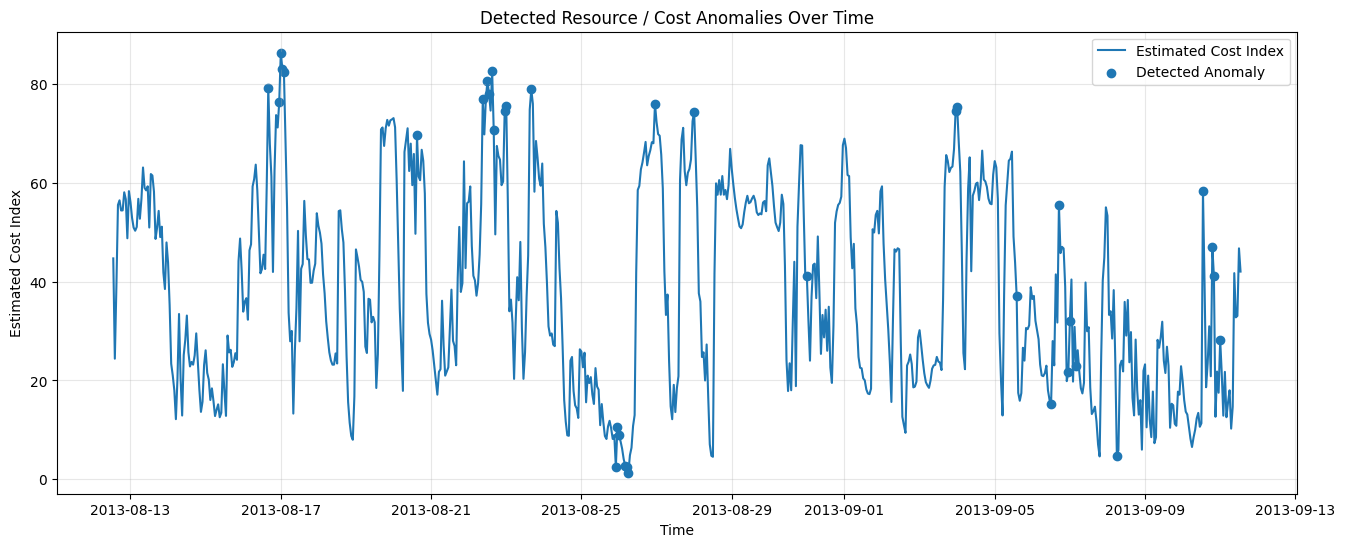

In [ ]:
import matplotlib.pyplot as plt

# Separate normal and anomalous observations
normal_data = hourly_anomaly_df[hourly_anomaly_df["anomaly_flag"] == 0]
anomaly_data = hourly_anomaly_df[hourly_anomaly_df["anomaly_flag"] == 1]

print("Normal observations:", len(normal_data))
print("Anomalies:", len(anomaly_data))

# Plot estimated cost index over time
plt.figure(figsize=(16, 6))

plt.plot(
    hourly_anomaly_df["time_bucket"],
    hourly_anomaly_df["estimated_cost_index"],
    label="Estimated Cost Index"
)

plt.scatter(
    anomaly_data["time_bucket"],
    anomaly_data["estimated_cost_index"],
    marker="o",
    label="Detected Anomaly"
)

plt.title("Detected Resource / Cost Anomalies Over Time")
plt.xlabel("Time")
plt.ylabel("Estimated Cost Index")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# COMPARE NORMAL VS ANOMALOUS OBSERVATIONS
# ============================================================

comparison_features = [
    "cpu_mean",
    "memory_mean_gb",
    "disk_activity_kbps",
    "network_activity_kbps",
    "active_vms",
    "resource_cost_index",
    "estimated_cost_index"
]

# Group by anomaly status
anomaly_comparison = (
    hourly_anomaly_df
    .groupby("anomaly_flag")[comparison_features]
    .agg(["mean", "median", "min", "max"])
)

# Rename group index
anomaly_comparison.index = anomaly_comparison.index.map({
    0: "Normal",
    1: "Anomaly"
})

print("NORMAL VS ANOMALY FEATURE COMPARISON")
print("=" * 70)

display(anomaly_comparison)

NORMAL VS ANOMALY FEATURE COMPARISON


cpu_mean                                memory_mean_gb  \
                  mean    median       min        max           mean   
anomaly_flag                                                           
Normal        7.810481  7.220378  2.208246  14.878450       0.563135   
Anomaly       8.704130  9.498448  2.072840  15.305289       0.814815   

                                           disk_activity_kbps              \
                median       min       max               mean      median   
anomaly_flag                                                                
Normal        0.536339  0.216732  1.218053          396.30062  352.575359   
Anomaly       1.003735  0.212679  1.562801          568.85335  522.527442   

              ...  active_vms         resource_cost_index                      \
              ...         min     max                mean    median       min   
anomaly_flag  ...                                                               
Normal        ...  810.083333  961.50            0.240323  0.230264  0.036818   
Anomaly       ...  593.500000  965.25            0.320634  0.400791  0.019946   

                       estimated_cost_index                                  
                   max                 mean     median       min        max  
anomaly_flag                                                                 
Normal        0.480156            37.571693  35.917797  4.109438  77.007539  
Anomaly       0.536530            50.777286  63.957547  1.335226  86.277015  

[2 rows x 28 columns]

In [ ]:
!pip install shap -q


In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
explainer = shap.TreeExplainer(improved_xgb)

shap_values = explainer.shap_values(X_val)

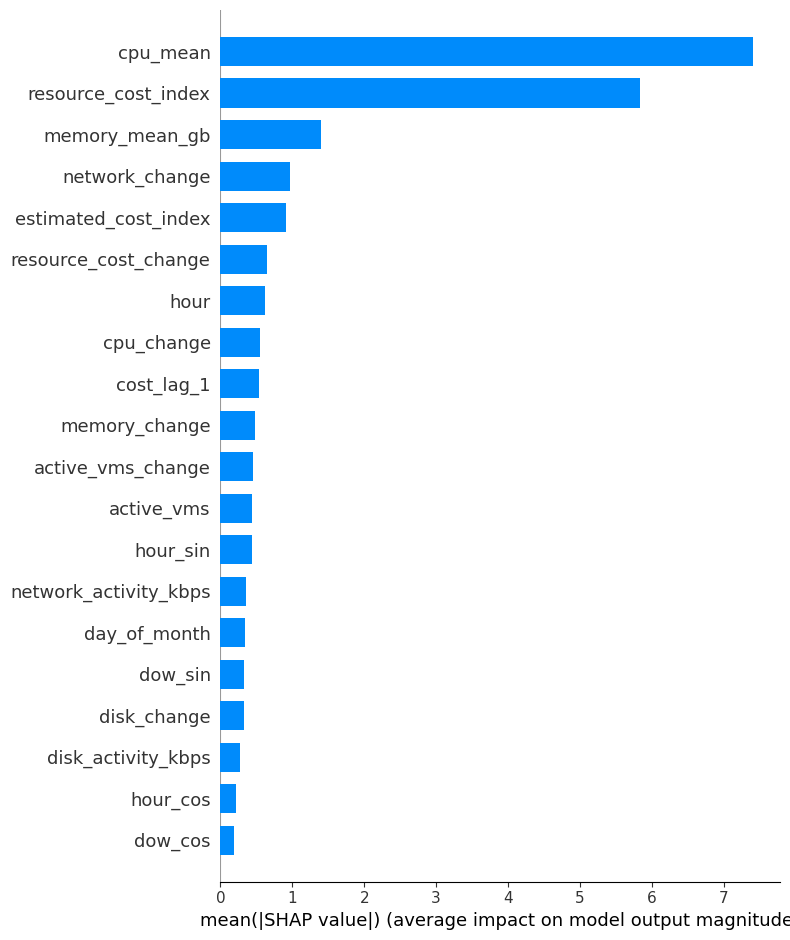

In [ ]:
shap.summary_plot(
    shap_values,
    X_val,
    plot_type="bar"
)

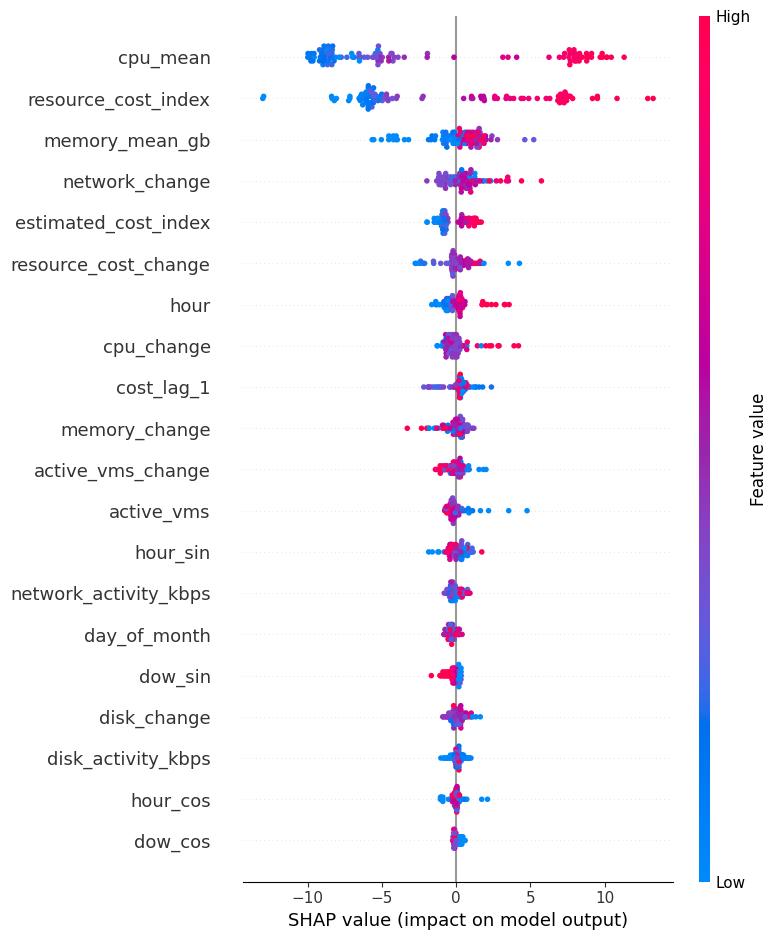

In [ ]:
shap.summary_plot(
    shap_values,
    X_val
)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Production predictions
# Current production model = Naive Baseline
# Predict next hour cost using the current hour cost

production_predictions = X_test["estimated_cost_index"].values
actual_costs = y_test.values

# Performance metrics
production_mae = mean_absolute_error(
    actual_costs,
    production_predictions
)

production_rmse = np.sqrt(
    mean_squared_error(
        actual_costs,
        production_predictions
    )
)

production_r2 = r2_score(
    actual_costs,
    production_predictions
)

print("PRODUCTION MODEL PERFORMANCE")
print("=" * 50)
print("Production model: Naive Baseline")
print(f"MAE  : {production_mae:.4f}")
print(f"RMSE : {production_rmse:.4f}")
print(f"R²   : {production_r2:.4f}")

PRODUCTION MODEL PERFORMANCE
Production model: Naive Baseline
MAE  : 7.8305
RMSE : 10.8280
R²   : 0.1411


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# ROLLING PERFORMANCE MONITORING
# ============================================================

monitoring_df = pd.DataFrame({
    "time_bucket": ml_df.iloc[train_size + val_size:]["time_bucket"].values,
    "actual_cost": actual_costs,
    "predicted_cost": production_predictions
})

# Absolute prediction error
monitoring_df["absolute_error"] = (
    monitoring_df["actual_cost"]
    - monitoring_df["predicted_cost"]
).abs()

# Squared prediction error
monitoring_df["squared_error"] = (
    monitoring_df["actual_cost"]
    - monitoring_df["predicted_cost"]
) ** 2

# Rolling performance metrics
window = 24   # 24-hour monitoring window

monitoring_df["rolling_mae"] = (
    monitoring_df["absolute_error"]
    .rolling(window=window, min_periods=1)
    .mean()
)

monitoring_df["rolling_rmse"] = (
    monitoring_df["squared_error"]
    .rolling(window=window, min_periods=1)
    .mean()
    .pow(0.5)
)

print("PERFORMANCE MONITORING DATASET")
print("=" * 60)

print(f"Monitoring observations: {len(monitoring_df)}")
print(f"Monitoring window      : {window} hours")

print("\nFirst 5 records:")
display(monitoring_df.head())

print("\nLast 5 records:")
display(monitoring_df.tail())

PERFORMANCE MONITORING DATASET
Monitoring observations: 109
Monitoring window      : 24 hours

First 5 records:


,time_bucket,actual_cost,predicted_cost,absolute_error,squared_error,rolling_mae,rolling_rmse
0,2013-09-07 00:00:00,40.416795,32.037608,8.379187,70.210774,8.379187,8.379187
1,2013-09-07 01:00:00,19.763919,40.416795,20.652876,426.541269,14.516031,15.759950
2,2013-09-07 02:00:00,30.830895,19.763919,11.066975,122.477942,13.366346,14.366976
3,2013-09-07 03:00:00,22.854520,30.830895,7.976375,63.622555,12.018853,13.065724
4,2013-09-07 04:00:00,26.109066,22.854520,3.254546,10.592068,10.265992,11.776626



Last 5 records:


,time_bucket,actual_cost,predicted_cost,absolute_error,squared_error,rolling_mae,rolling_rmse
104,2013-09-11 08:00:00,41.699293,14.681374,27.017919,729.967930,11.513258,15.865968
105,2013-09-11 09:00:00,32.758115,41.699293,8.941178,79.944671,11.839789,15.969006
106,2013-09-11 10:00:00,33.046694,32.758115,0.288580,0.083278,11.734891,15.958839
107,2013-09-11 11:00:00,46.714217,33.046694,13.667522,186.801166,12.274994,16.200222
108,2013-09-11 12:00:00,42.016717,46.714217,4.697500,22.066506,10.511347,13.085371


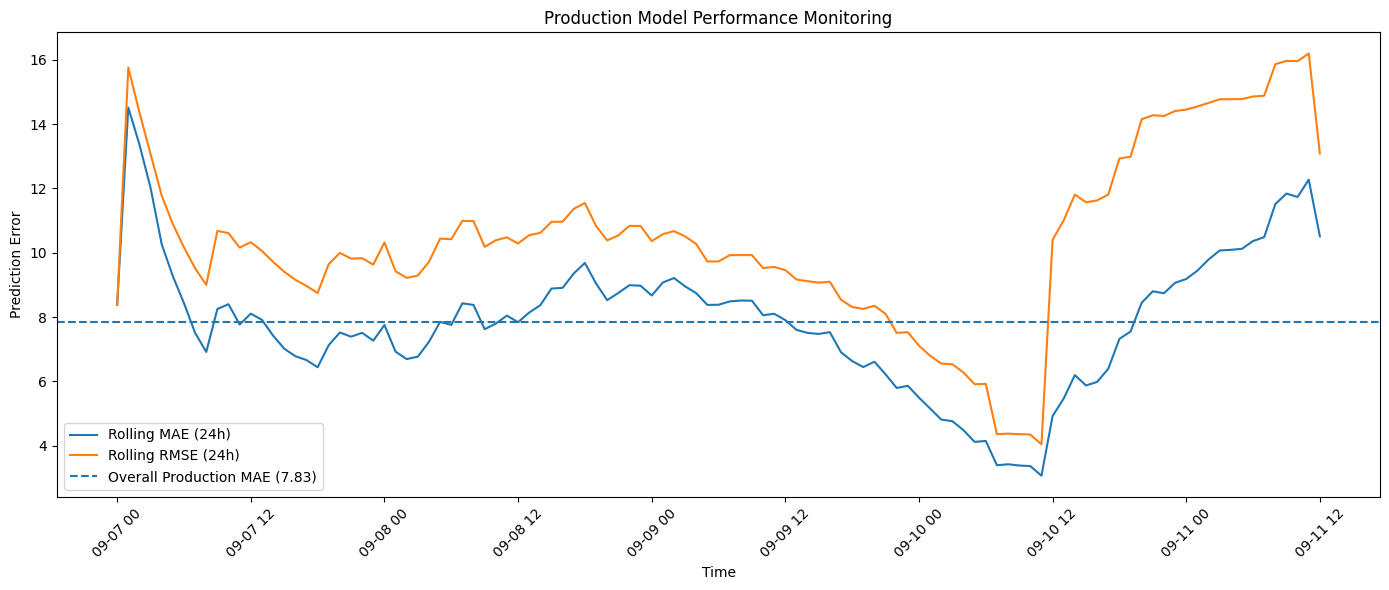

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# PERFORMANCE MONITORING VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    monitoring_df["time_bucket"],
    monitoring_df["rolling_mae"],
    label="Rolling MAE (24h)"
)

plt.plot(
    monitoring_df["time_bucket"],
    monitoring_df["rolling_rmse"],
    label="Rolling RMSE (24h)"
)

plt.axhline(
    production_mae,
    linestyle="--",
    label=f"Overall Production MAE ({production_mae:.2f})"
)

plt.title("Production Model Performance Monitoring")
plt.xlabel("Time")
plt.ylabel("Prediction Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# PERFORMANCE DEGRADATION DETECTION
# ============================================================

# Reference production performance
reference_mae = production_mae

# Allow 20% degradation before considering performance abnormal
degradation_tolerance = 0.20

mae_threshold = reference_mae * (1 + degradation_tolerance)

# Is each hour above the threshold?
monitoring_df["mae_threshold_exceeded"] = (
    monitoring_df["rolling_mae"] > mae_threshold
)

# Require sustained degradation for 6 consecutive hours
consecutive_hours = 6

monitoring_df["performance_alert"] = (
    monitoring_df["mae_threshold_exceeded"]
    .rolling(
        window=consecutive_hours,
        min_periods=consecutive_hours
    )
    .sum()
    .eq(consecutive_hours)
)

print("PERFORMANCE DEGRADATION MONITOR")
print("=" * 55)

print(f"Reference MAE       : {reference_mae:.4f}")
print(f"Tolerance           : {degradation_tolerance * 100:.0f}%")
print(f"Alert threshold     : {mae_threshold:.4f}")
print(f"Consecutive hours   : {consecutive_hours}")

print(
    "\nHours above threshold:",
    monitoring_df["mae_threshold_exceeded"].sum()
)

print(
    "Performance alert hours:",
    monitoring_df["performance_alert"].sum()
)

# First time sustained degradation is detected
alerts = monitoring_df[
    monitoring_df["performance_alert"]
]

if len(alerts) > 0:

    first_alert = alerts.iloc[0]

    print("\nPERFORMANCE DEGRADATION DETECTED")
    print("-" * 55)

    print("First alert time :", first_alert["time_bucket"])
    print(
        "Rolling MAE      :",
        round(first_alert["rolling_mae"], 4)
    )
    print(
        "Threshold        :",
        round(mae_threshold, 4)
    )

    retraining_trigger = True

else:

    print("\nNo sustained performance degradation detected.")

    retraining_trigger = False

print("\nRetraining trigger:", retraining_trigger)

PERFORMANCE DEGRADATION MONITOR
Reference MAE       : 7.8305
Tolerance           : 20%
Alert threshold     : 9.3965
Consecutive hours   : 6

Hours above threshold: 17
Performance alert hours: 7

PERFORMANCE DEGRADATION DETECTED
-------------------------------------------------------
First alert time : 2013-09-11 06:00:00
Rolling MAE      : 10.3634
Threshold        : 9.3965

Retraining trigger: True


In [ ]:
# ============================================================
# UNIFIED DRIFT + PERFORMANCE RETRAINING POLICY
# ============================================================

# Features available at prediction / monitoring time
production_drift_features = [
    "cpu_mean",
    "memory_mean_gb",
    "disk_activity_kbps",
    "network_activity_kbps",
    "active_vms",
    "resource_cost_index",
    "estimated_cost_index"
]

# PSI threshold
PSI_THRESHOLD = 0.25

# Get PSI values only for production-observable features
production_psi = psi_df[
    psi_df["Feature"].isin(production_drift_features)
].copy()

production_psi["significant_drift"] = (
    production_psi["PSI"] > PSI_THRESHOLD
)

# Count drifted features
drifted_feature_count = int(
    production_psi["significant_drift"].sum()
)

drift_detected = drifted_feature_count > 0

# Performance degradation from previous monitoring cell
performance_degradation_detected = retraining_trigger

# ------------------------------------------------------------
# Unified retraining rule
# ------------------------------------------------------------

# Trigger retraining if either:
# 1. significant feature drift is detected
# OR
# 2. sustained model-performance degradation is detected

final_retraining_trigger = (
    drift_detected
    or performance_degradation_detected
)

print("UNIFIED MLOPS MONITORING DECISION")
print("=" * 60)

print("\nDrift Monitoring")
print("-" * 40)

display(
    production_psi[
        ["Feature", "PSI", "significant_drift"]
    ].sort_values("PSI", ascending=False)
)

print(f"\nPSI threshold           : {PSI_THRESHOLD}")
print(f"Drifted features        : {drifted_feature_count}")
print(f"Feature drift detected  : {drift_detected}")

print("\nPerformance Monitoring")
print("-" * 40)

print(
    "Performance degradation detected:",
    performance_degradation_detected
)

print("\nFINAL DECISION")
print("=" * 60)

if final_retraining_trigger:
    print("RETRAINING TRIGGERED")

    if drift_detected:
        print("Reason: Significant feature/data drift detected.")

    if performance_degradation_detected:
        print("Reason: Sustained model performance degradation detected.")
else:
    print("NO RETRAINING REQUIRED")

print("\nFinal retraining trigger:", final_retraining_trigger)


UNIFIED MLOPS MONITORING DECISION

Drift Monitoring
----------------------------------------


,Feature,PSI,significant_drift
0,active_vms,8.721684,True
1,cpu_mean,3.768891,True
3,resource_cost_index,2.936494,True
4,estimated_cost_index,2.936494,True
5,disk_activity_kbps,0.588969,True
6,memory_mean_gb,0.586056,True
7,network_activity_kbps,0.069097,False



PSI threshold           : 0.25
Drifted features        : 6
Feature drift detected  : True

Performance Monitoring
----------------------------------------
Performance degradation detected: True

FINAL DECISION
RETRAINING TRIGGERED
Reason: Significant feature/data drift detected.
Reason: Sustained model performance degradation detected.

Final retraining trigger: True
